In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [8]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("Soft_Drink_Sales.csv")
df.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Charlie Brown,UK,Diet Cola,05/06/2022,"$6,180.67",280
1,Fiona Gallagher,India,Orange Fizz,16/08/2022,"$1,042.75",96
2,Fiona Gallagher,Japan,Orange Fizz,22/03/2022,"$7,607.87",414
3,Alice Johnson,USA,Cola Classic,18/03/2022,$558.67,318
4,Alice Johnson,Japan,Root Beer Floats,07/11/2022,"$1,183.80",333
5,Diana Prince,Japan,Root Beer Floats,25/07/2022,"$6,527.24",233
6,Charlie Brown,Germany,Cherry Soda,17/11/2022,"$10,244.31",229
7,Bob Smith,Canada,Root Beer Floats,23/07/2022,"$4,924.72",439
8,Diana Prince,USA,Lemon Lime Sparkle,04/05/2022,"$2,255.46",472
9,Alice Johnson,Australia,Cherry Soda,22/04/2022,"$5,663.13",315


In [9]:
df.dtypes

Sales Person     object
Country          object
Product          object
Date             object
Amount           object
Boxes Shipped     int64
dtype: object

In [10]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'])

df.dtypes

Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                  float64
Boxes Shipped             int64
dtype: object

In [11]:
df.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [12]:
df_missing = df.copy()
df_missing.loc[0:5, 'Amount'] = np.nan
df_missing.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           6
Boxes Shipped    0
dtype: int64

In [13]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (50, 6)
After removing some values:  (50, 6)


In [14]:
df_missing.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Charlie Brown,UK,Diet Cola,2022-06-05,NaN,280
1,Fiona Gallagher,India,Orange Fizz,2022-08-16,NaN,96
2,Fiona Gallagher,Japan,Orange Fizz,2022-03-22,NaN,414
3,Alice Johnson,USA,Cola Classic,2022-03-18,NaN,318
4,Alice Johnson,Japan,Root Beer Floats,2022-11-07,NaN,333
5,Diana Prince,Japan,Root Beer Floats,2022-07-25,NaN,233
6,Charlie Brown,Germany,Cherry Soda,2022-11-17,10244.31,229
7,Bob Smith,Canada,Root Beer Floats,2022-07-23,4924.72,439
8,Diana Prince,USA,Lemon Lime Sparkle,2022-05-04,2255.46,472
9,Alice Johnson,Australia,Cherry Soda,2022-04-22,5663.13,315


In [15]:
df_missing.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Charlie Brown,UK,Diet Cola,2022-06-05,NaN,280
1,Fiona Gallagher,India,Orange Fizz,2022-08-16,NaN,96
2,Fiona Gallagher,Japan,Orange Fizz,2022-03-22,NaN,414
3,Alice Johnson,USA,Cola Classic,2022-03-18,NaN,318
4,Alice Johnson,Japan,Root Beer Floats,2022-11-07,NaN,333
5,Diana Prince,Japan,Root Beer Floats,2022-07-25,NaN,233
6,Charlie Brown,Germany,Cherry Soda,2022-11-17,10244.31,229
7,Bob Smith,Canada,Root Beer Floats,2022-07-23,4924.72,439
8,Diana Prince,USA,Lemon Lime Sparkle,2022-05-04,2255.46,472
9,Alice Johnson,Australia,Cherry Soda,2022-04-22,5663.13,315


In [16]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['Amount'].fillna(df_imputed_mean['Amount'].mean(), inplace=True)

df_imputed_mean.isna().sum()

C:\Users\huawei\AppData\Local\Temp\ipykernel_7096\1929271123.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_mean['Amount'].fillna(df_imputed_mean['Amount'].mean(), inplace=True)


Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [17]:
df_imputed_mean.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Charlie Brown,UK,Diet Cola,2022-06-05,7172.949091,280
1,Fiona Gallagher,India,Orange Fizz,2022-08-16,7172.949091,96
2,Fiona Gallagher,Japan,Orange Fizz,2022-03-22,7172.949091,414
3,Alice Johnson,USA,Cola Classic,2022-03-18,7172.949091,318
4,Alice Johnson,Japan,Root Beer Floats,2022-11-07,7172.949091,333
5,Diana Prince,Japan,Root Beer Floats,2022-07-25,7172.949091,233
6,Charlie Brown,Germany,Cherry Soda,2022-11-17,10244.310000,229
7,Bob Smith,Canada,Root Beer Floats,2022-07-23,4924.720000,439
8,Diana Prince,USA,Lemon Lime Sparkle,2022-05-04,2255.460000,472
9,Alice Johnson,Australia,Cherry Soda,2022-04-22,5663.130000,315


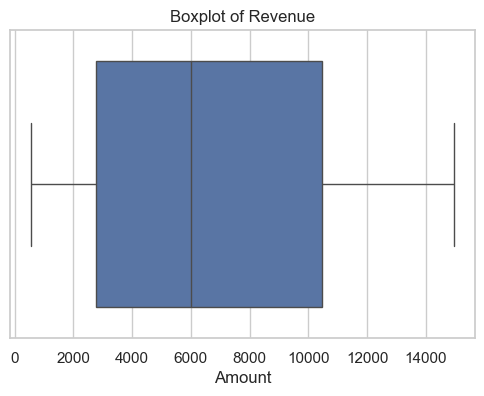

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Amount'])
plt.title("Boxplot of Revenue")
plt.show()

In [24]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1


lower = Q1 - 0.1 * IQR
upper = Q3 + 0.1 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
outliers.head(15)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
1,Fiona Gallagher,India,Orange Fizz,2022-08-16,1042.75,96
3,Alice Johnson,USA,Cola Classic,2022-03-18,558.67,318
4,Alice Johnson,Japan,Root Beer Floats,2022-11-07,1183.80,333
14,Ethan Hunt,UK,Diet Cola,2022-12-06,1002.96,454
23,Alice Johnson,Australia,Diet Cola,2022-04-25,1059.56,38
24,Bob Smith,Canada,Cola Classic,2022-12-26,12189.59,358
25,Alice Johnson,USA,Orange Fizz,2022-03-01,12171.88,476
26,Charlie Brown,Canada,Ginger Ale,2022-06-24,13715.45,338
28,Diana Prince,USA,Cherry Soda,2022-04-26,1160.84,339
29,Bob Smith,Canada,Cola Classic,2022-08-07,14218.33,106


In [25]:
df_no_outliers = df[(df['Amount'] >= lower) & (df['Amount'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (50, 6)
After removing outliers:  (32, 6)


In [26]:
lower_cap = df['Amount'].quantile(0.05)
upper_cap = df['Amount'].quantile(0.95)

df_capped = df.copy()
df_capped['Amount'] = df_capped['Amount'].clip(lower_cap, upper_cap)

In [27]:
df[['Amount', 'Boxes Shipped']].head()

,Amount,Boxes Shipped
0,6180.67,280
1,1042.75,96
2,7607.87,414
3,558.67,318
4,1183.80,333


In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Amount', 'Boxes Shipped']].copy()

df_scaled[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Amount,Boxes Shipped
0,0.390540,0.530702
1,0.033627,0.127193
2,0.489683,0.824561
3,0.000000,0.614035
4,0.043426,0.646930


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Amount', 'Boxes Shipped']].copy()

df_standardized[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Amount,Boxes Shipped
0,-0.136124,-0.118217
1,-1.314457,-1.620418
2,0.191191,0.975778
3,-1.425476,0.192020
4,-1.282108,0.314483


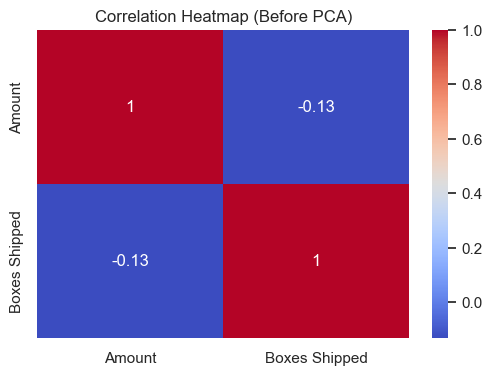

In [32]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Amount','Boxes Shipped']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [33]:
from sklearn.decomposition import PCA

X = df_standardized[['Amount', 'Boxes Shipped']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.56558314 0.43441686]


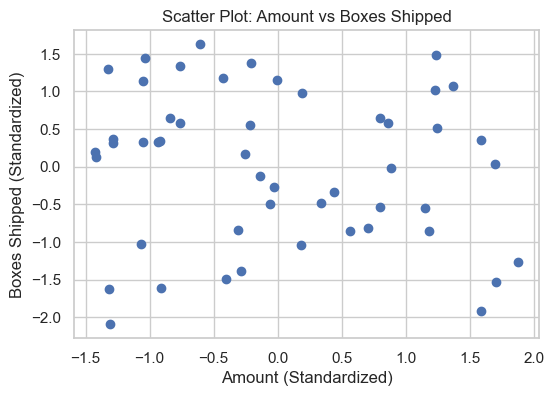

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(df_standardized['Amount'], df_standardized['Boxes Shipped'])
plt.xlabel("Amount (Standardized)")
plt.ylabel("Boxes Shipped (Standardized)")
plt.title("Scatter Plot: Amount vs Boxes Shipped")
plt.show()